In [1]:
%load_ext autoreload 
%autoreload 2

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from datetime import datetime
from pyetc_ifs import ETC,WST,iredMUSE, get_seeing_fwhm, __version__
from scipy.optimize import brentq
from tqdm.notebook import tqdm
import json, pickle
import os
plt.rcParams.update({'font.size': 12})
file_dir = "/home/nbouche/Python_git/pyetc_iredmuse/images/"
print(f"pyetc_wst version {__version__}")

pyetc_wst version 0.1


In [2]:
wst = WST(log = 'WARNING', skip_dataload = False)
wst.info()
instru=wst
ifs_channels=np.array(instru.ifs['channels'])
                  

In [3]:
redmuse=iredMUSE(log='DEBUG', skip_dataload=False)
redmuse.info()

[DEBUG] iredMUSE.__init__ processing time: 3.9341 seconds
[INFO] ETC version 0.1 release date 26 June 2026
[INFO] 	- Initial version
[INFO] Telescope Based on Prelim Concept version 26/06/2026
[INFO] Diameter: 8.00 m Eff. Area IFS: 48.5 m2
[INFO] IFS type IFS Channel zband
[INFO] 	 Throughput model: Throughput estimations by Nicolas Bouché
[INFO] 	 Configuration version: 26/06/2026
[INFO] 	 Spaxel size: 0.22 arcsec Image Quality tel and ins fwhm: 0.10 and 0.13 arcsec beta: 2.80 
[INFO] 	 Wavelength range [ 9330. 11300.] A step 1.00 A LSF 2.2 pix Npix 1971
[INFO] 	 Instrument transmission peak 0.30 at 9330 - min 0.30 at 9330
[INFO] 	 Detector RON 7.0 e- Dark 72.0 e-/h
[INFO] IFS type IFS Channel Jband
[INFO] 	 Throughput model: Throughput estimations by Nicolas Bouché
[INFO] 	 Configuration version: 26/06/2026
[INFO] 	 Spaxel size: 0.22 arcsec Image Quality tel and ins fwhm: 0.10 and 0.13 arcsec beta: 2.80 
[INFO] 	 Wavelength range [11300. 12000.] A step 1.00 A LSF 2.2 pix Npix 701
[IN

In [4]:
instru=redmuse
ifs_channels=np.array(instru.ifs['channels'])

In [5]:
def get_specinfo(full_obs, inst=instru):
    insfam = getattr(inst, full_obs["INS"])
    ins = insfam[full_obs["CH"]]
    lsf = ins['lsfpix']*ins['dlbda']
    dl = ins['dlbda']
    dr = full_obs['COADD_WL']*ins['dlbda']
    l1,l2 = ins['lbda1'],ins['lbda2']
    return dr,lsf,l1,l2,dl,ins

def optim_snr2(con, im, spe, lbda, coadd0, inst=instru):
    global niter
    snr1 = 0
    for coadd in np.arange(coadd0, 1, -1):
        niter += 1
        inst.obs['ima_coadd'] = coadd
        res_snr2 = inst.snr_at_wave(con, im, spe, wave_target=lbda)
        snr2 = res_snr2['snr_aperture']
        #print(coadd, snr2)
        if snr2 < snr1:
            break
        coadd1 = coadd
        snr1 = snr2
    for coadd in np.arange(coadd0+1, 20):
        niter += 1
        inst.obs['ima_coadd'] = coadd
        res_snr2 = inst.snr_at_wave(con, im, spe, wave_target=lbda)
        snr2 = res_snr2['snr_aperture']
        #print(coadd, snr2)
        if snr2 < snr1:
            break
        coadd1 = coadd
        snr1 = snr2
    return snr1,coadd1    

# Input Parameters

In [6]:
common_obs = {
    "NDIT": 3,
    "DIT": 1200,    
    "PWV": 1,
    "AM": 1.2,
    "SKYCALC": False,   
    "MAG_SYS": 'AB',
    "MAG_FIL": 'rSDSS',    
    "Z": 0,   
    "SEE": 0.8,
}
ifs_obs_ps = {
    "INS": "ifs",
    "GLAO": False,
    "Obj_Spat_Dis": 'ps', 
    "Obj_SED": 'uniform',   
    "COADD_WL": 3,  
    "SNR_REQ" : 3,
    "COADD_XY": 'best',
}
ifs_obs_psl = {
    "INS": "ifs",
    "GLAO": False,
    "Obj_Spat_Dis": 'ps', 
    "Obj_SED": 'line',   
    "SEL_FWHM": 5, #in A
    "COADD_WL": 3,  
    "SNR_REQ" : 5,
    "COADD_XY": 'best',
}
ifs_obs_sb = {
    "INS": "ifs",
    "Obj_Spat_Dis": 'sb', 
    "Obj_SED": 'uniform',   
    "COADD_WL": 3,    
    "COADD_XY": 16,
    "SNR_REQ" : 3,
}
moslr_obs_ps = {
    "INS": "moslr",
    "SEE": 0.75,
    "Obj_SED": 'uniform',  
    "Obj_Spat_Dis": 'ps',   
    "COADD_WL": 7,
    "OBJ_FIB_DISP": 0.15,
    "SNR_REQ" : 3,
}
moshr_obs_ps = {
    "INS": "moshr",
    "SEE": 0.75,
    "Obj_SED": 'uniform',  
    "Obj_Spat_Dis": 'ps',   
    "COADD_WL": 4,
    "OBJ_FIB_DISP": 0.15,
    "SNR_REQ" : 3,
}

# IFS point source limiting magnitude

In [7]:
def maglim_ifs(full_obs, lbda, snr, mags, dmag=0.1, dsnr=0.1):
    mag = brentq(zeromag_ifs, mags[0], mags[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return mag
def zeromag_ifs(mag, snr0, full_obs, lbda, inst=instru):
    full_obs['OBJ_MAG'] = mag
    con, ob, spe, im, spe_input = inst.build_obs_full(full_obs)
    res = inst.snr_at_wave(con, im, spe, lbda)
    return res['snr_aperture']-snr0

In [8]:
full_obs = common_obs | ifs_obs_ps    
mags = [20,30]
snr = full_obs["SNR_REQ"]
difs = []
for fli in [0,0.5,1]:
    dm = dict(fli=fli, ins='ifs')
    full_obs["FLI"] = fli
    print(f"Moon : {fli}")
    dlim = []
    for ch in ifs_channels:
        full_obs['CH'] = ch
        con, ob, spe, im, spe_input = instru.build_obs_full(full_obs)
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ = full_obs['NDIT']*full_obs['DIT']/3600
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ} hour(s) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/10)
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves):  
            try:
                mag = maglim_ifs(full_obs, lbda, snr, mags)
            except:
                mag = maglim_ifs(full_obs, lbda, snr, mags=[10,30])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(mag)
            mags = [mag-0.5,mag+0.5]
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    difs.append(dm)

Moon : 0
Instrument ifs Channel zband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 3.0 A (3 pix) LSF 2.2 A


  0%|          | 0/65 [00:00<?, ?it/s]

Instrument ifs Channel Jband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 3.0 A (3 pix) LSF 2.2 A


  0%|          | 0/23 [00:00<?, ?it/s]

Instrument ifs Channel zJband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 6.0 A (3 pix) LSF 4.4 A


...

  0%|          | 0/65 [00:00<?, ?it/s]

Instrument ifs Channel Jband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 3.0 A (3 pix) LSF 2.2 A


  0%|          | 0/23 [00:00<?, ?it/s]

Instrument ifs Channel zJband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 6.0 A (3 pix) LSF 4.4 A


  0%|          | 0/44 [00:00<?, ?it/s]

Text(0.02, 0.9, 'Computed 2026-06-28')

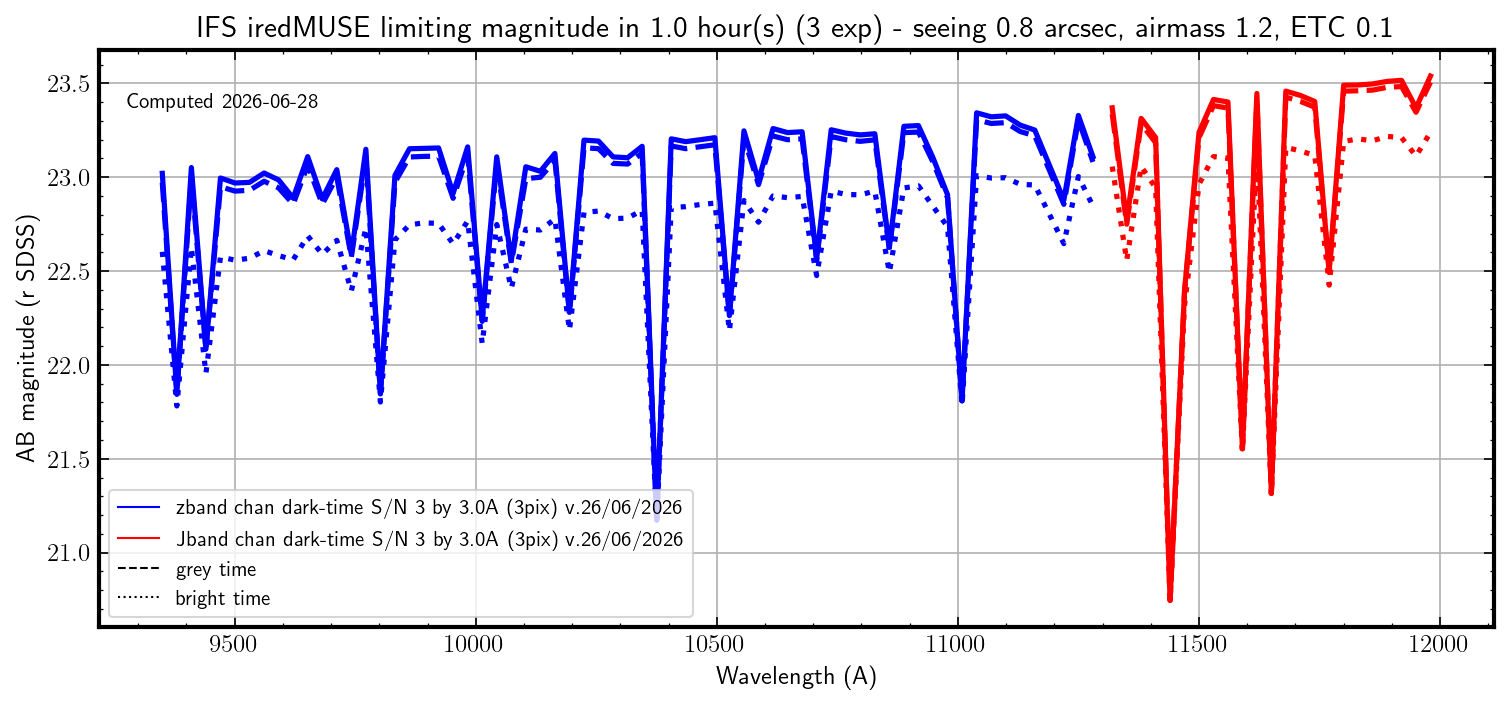

In [11]:
fig,ax = plt.subplots(1,1,figsize=(12,5))
labs = []
for d,c in zip(difs[0]['dlim'], ['blue','red']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.1f}A ({d['pixspec']}pix) v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(difs[1]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(difs[2]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('AB magnitude (r SDSS)')
see = 'GLAO' if full_obs['GLAO'] else f"seeing {ob['seeing']} arcsec"
integ = full_obs['NDIT']*full_obs['DIT']/3600
ax.set_title(f"IFS {instru.name} limiting magnitude in {integ} hour(s) ({full_obs['NDIT']} exp) - {see}, airmass {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [13]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(file_dir,f"{today}_{instru.name}_IFS_limiting_mag.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(file_dir,f"{today}_{instru.name}_IFS_limiting_mag.json")
with open(outres, "w") as f:
    json.dump(difs, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-06-28_iredMUSE_IFS_limiting_mag.jpg
Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-06-28_iredMUSE_IFS_limiting_mag.json


# IFS surface brightness limiting flux

In [14]:
def maglim_ifs_sb(full_obs, lbda, snr, mags, dmag=0.1, dsnr=0.1):
    mag = brentq(zeromag_ifs_sb, mags[0], mags[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return mag
def zeromag_ifs_sb(mag, snr0, full_obs, lbda, inst=instru):
    full_obs['OBJ_MAG'] = mag
    con, ob, spe, im, spe_input = inst.build_obs_full(full_obs)
    res = inst.snr_at_wave(con, im, spe, lbda)
    return res['snr_aperture']-snr0

In [15]:
full_obs = common_obs | ifs_obs_sb    
mags = [10,30]
snr = full_obs["SNR_REQ"]
difs = []
for fli in [0,0.5,1]:
    print(f"Moon : {fli}")
    dm = dict(fli=fli, ins='ifs')
    full_obs["FLI"] = fli
    dlim = []
    for ch in ifs_channels:
        full_obs['CH'] = ch
        con, ob, spe, im, spe_input = instru.build_obs_full(full_obs)
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ = full_obs['NDIT']*full_obs['DIT']/3600
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ} hour(s) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/10)
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves):  
            try:
                mag = maglim_ifs_sb(full_obs, lbda, snr, mags)
            except:
                mag = maglim_ifs_sb(full_obs, lbda, snr, mags=[10,30])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(mag)
            mags = [mag-0.5,mag+0.5]
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    difs.append(dm)

Moon : 0
Instrument ifs Channel zband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 3.0 A (3 pix) LSF 2.2 A


  0%|          | 0/65 [00:00<?, ?it/s]

Instrument ifs Channel Jband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 3.0 A (3 pix) LSF 2.2 A


  0%|          | 0/23 [00:00<?, ?it/s]

Instrument ifs Channel zJband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 6.0 A (3 pix) LSF 4.4 A


...

  0%|          | 0/65 [00:00<?, ?it/s]

Instrument ifs Channel Jband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 3.0 A (3 pix) LSF 2.2 A


  0%|          | 0/23 [00:00<?, ?it/s]

Instrument ifs Channel zJband Version 26/06/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 6.0 A (3 pix) LSF 4.4 A


  0%|          | 0/44 [00:00<?, ?it/s]

Text(0.02, 0.9, 'Computed 2026-06-28')

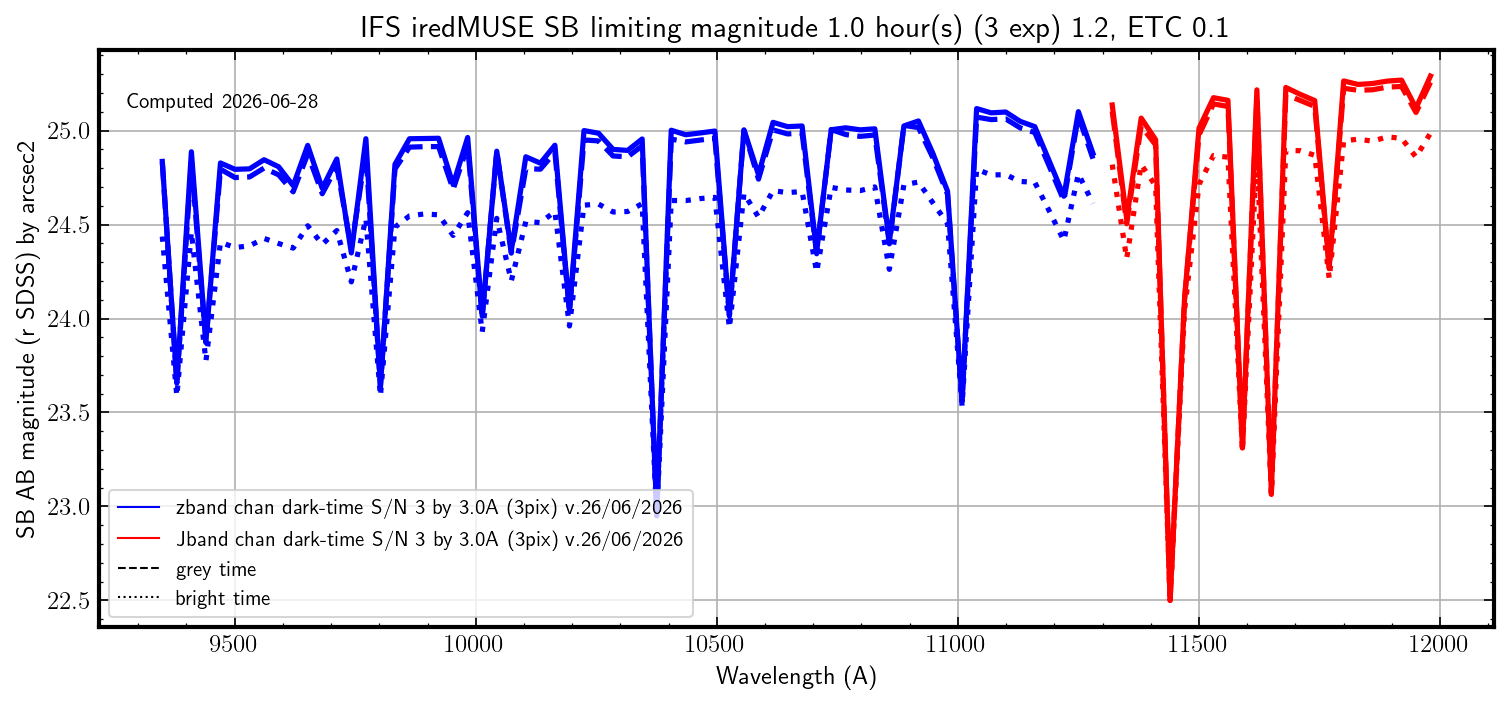

In [16]:
fig,ax = plt.subplots(1,1,figsize=(12,5))
labs = []
for d,c in zip(difs[0]['dlim'], ['blue','red']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.1f}A ({d['pixspec']}pix) v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(difs[1]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(difs[2]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('SB AB magnitude (r SDSS) by arcsec2')
integ = full_obs['NDIT']*full_obs['DIT']/3600
ax.set_title(f"IFS {instru.name} SB limiting magnitude {integ} hour(s) ({full_obs['NDIT']} exp) {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [17]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(file_dir,f"{today}_{instru.name}_IFS_SBlimiting_mag.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(file_dir,f"{today}_{instru.name}_IFS_SBlimiting_mag.json")
with open(outres, "w") as f:
    json.dump(difs, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-06-28_iredMUSE_IFS_SBlimiting_mag.jpg
Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-06-28_iredMUSE_IFS_SBlimiting_mag.json


# IFS limiting emission flux

In [21]:
def fluxlim_ifs(full_obs, lbda, snr, fluxes, dmag=0.1, dsnr=0.1):
    flux = brentq(zeroflux_ifs, fluxes[0], fluxes[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return flux*1.e-20
def zeroflux_ifs(flux, snr0, full_obs, lbda, inst=instru):
    full_obs['SEL_FLUX'] = flux*1.e-20
    full_obs['SEL_CWAV'] = lbda
    con, ob, spe, im, spe_input = inst.build_obs_full(full_obs)
    res = inst.snr_from_source(con, im, spe)
    spsignal = res['spec']['nph_source']
    spnoise = res['spec']['noise']['tot']
    snrmax = snr_sum(spsignal,spnoise)
    #print(flux,snrmax)
    return snrmax-snr0

In [22]:
def snr_sum(signal, noise):
    signal = signal.data
    noise = noise.data
    variance = noise**2
    mask = variance > 0
    s = signal[mask]
    v = variance[mask]
    snr = np.sum(s) / np.sqrt(np.sum(v))
    return snr

In [23]:
full_obs = common_obs | ifs_obs_psl   
snr = full_obs["SNR_REQ"]
fluxes = [1,100000]
difs = []
for fli in [0,0.5,1]:
    print(f"Moon : {fli}")
    dm = dict(fli=fli, ins='ifs')
    full_obs["FLI"] = fli
    dlim = []
    for ch in ifs_channels:
        full_obs['CH'] = ch
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ = full_obs['NDIT']*full_obs['DIT']/3600
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ} hour(s) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/10)
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves): 
            try:
                flux = fluxlim_ifs(full_obs, lbda, snr, fluxes)
            except:
                flux = fluxlim_ifs(full_obs, lbda, snr, fluxes=[1,100000])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(flux)
            fluxes = [flux*1.e20/2,flux*1.e20*2]
            #print (flux,fluxes)
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    difs.append(dm)

Moon : 0
Instrument ifs Channel zband Version 26/06/2026
Limiting magnitude for S/N = 5 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 3.0 A (3 pix) LSF 2.2 A


  0%|          | 0/65 [00:00<?, ?it/s]

[DEBUG] Override snr_wave with wave_line_center: 9350.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 4 (at 9350.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[DEBUG] Total processing time: 0.05727505683898926 seconds
[DEBUG] ---- ETC Summary ----
[DEBUG] Instrument: ifs - Channel: zband
[DEBUG] Spec type: line | Ima type: ps
[DEBUG] DIT: 1200 s | NDIT: 3 | Coadd: 4
[DEBUG] Wavelength range: 9330.0 - 11300.0 AA
[DEBUG] Rebinning factor (spbin): 3
[DEBUG] SNR (peak) at lam=9350.0 AA: 0.00
[DEBUG] SNR (aperture) at lam=9350.0 AA: 0.00
[DEBUG] SNR (aperture rebinned) at lam=9350.0 AA: 0.00
[DEBUG] Fraction of saturated pixels: None
[DEBUG] ---------------------
[DEBUG] Override snr_wave with wave_line_center: 9350.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 6 (at 9350.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[DEBUG] To

  0%|          | 0/23 [00:00<?, ?it/s]

[DEBUG] Override snr_wave with wave_line_center: 11320.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 4 (at 11320.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[DEBUG] Total processing time: 0.03802204132080078 seconds
[DEBUG] ---- ETC Summary ----
[DEBUG] Instrument: ifs - Channel: Jband
[DEBUG] Spec type: line | Ima type: ps
[DEBUG] DIT: 1200 s | NDIT: 3 | Coadd: 4
[DEBUG] Wavelength range: 11300.0 - 12000.0 AA
[DEBUG] Rebinning factor (spbin): 3
[DEBUG] SNR (peak) at lam=11320.0 AA: 1.58
[DEBUG] SNR (aperture) at lam=11320.0 AA: 4.19
[DEBUG] SNR (aperture rebinned) at lam=11320.0 AA: 4.12
[DEBUG] Fraction of saturated pixels: None
[DEBUG] ---------------------
[DEBUG] Override snr_wave with wave_line_center: 11320.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 4 (at 11320.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[D

...

[DEBUG] Override snr_wave with wave_line_center: 9350.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 4 (at 9350.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[DEBUG] Total processing time: 0.031209707260131836 seconds
[DEBUG] ---- ETC Summary ----
[DEBUG] Instrument: ifs - Channel: zband
[DEBUG] Spec type: line | Ima type: ps
[DEBUG] DIT: 1200 s | NDIT: 3 | Coadd: 4
[DEBUG] Wavelength range: 9330.0 - 11300.0 AA
[DEBUG] Rebinning factor (spbin): 3
[DEBUG] SNR (peak) at lam=9350.0 AA: 1.62
[DEBUG] SNR (aperture) at lam=9350.0 AA: 4.39
[DEBUG] SNR (aperture rebinned) at lam=9350.0 AA: 6.27
[DEBUG] Fraction of saturated pixels: None
[DEBUG] ---------------------
[DEBUG] Override snr_wave with wave_line_center: 9350.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 4 (at 9350.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[DEBUG] T

  0%|          | 0/23 [00:00<?, ?it/s]

[DEBUG] Override snr_wave with wave_line_center: 11320.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 4 (at 11320.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[DEBUG] Total processing time: 0.056963205337524414 seconds
[DEBUG] ---- ETC Summary ----
[DEBUG] Instrument: ifs - Channel: Jband
[DEBUG] Spec type: line | Ima type: ps
[DEBUG] DIT: 1200 s | NDIT: 3 | Coadd: 4
[DEBUG] Wavelength range: 11300.0 - 12000.0 AA
[DEBUG] Rebinning factor (spbin): 3
[DEBUG] SNR (peak) at lam=11320.0 AA: 1.40
[DEBUG] SNR (aperture) at lam=11320.0 AA: 3.70
[DEBUG] SNR (aperture rebinned) at lam=11320.0 AA: 4.05
[DEBUG] Fraction of saturated pixels: None
[DEBUG] ---------------------
[DEBUG] Override snr_wave with wave_line_center: 11320.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 4 (at 11320.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[

  0%|          | 0/44 [00:00<?, ?it/s]

[DEBUG] Override snr_wave with wave_line_center: 9350.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 4 (at 9350.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[DEBUG] Total processing time: 0.03685569763183594 seconds
[DEBUG] ---- ETC Summary ----
[DEBUG] Instrument: ifs - Channel: zJband
[DEBUG] Spec type: line | Ima type: ps
[DEBUG] DIT: 1200 s | NDIT: 3 | Coadd: 4
[DEBUG] Wavelength range: 9330.0 - 12000.0 AA
[DEBUG] Rebinning factor (spbin): 3
[DEBUG] SNR (peak) at lam=9350.0 AA: 0.52
[DEBUG] SNR (aperture) at lam=9350.0 AA: 1.41
[DEBUG] SNR (aperture rebinned) at lam=9350.0 AA: 2.07
[DEBUG] Fraction of saturated pixels: None
[DEBUG] ---------------------
[DEBUG] Override snr_wave with wave_line_center: 9350.0
[INFO] Sky taken from static files
[DEBUG] Spectrum convolved with LSF of 2.2 pixels
[INFO] Optimal coadd: 4 (at 9350.0 AA, initial guess=4)
[DEBUG] Rebinned SNR computed with factor 3
[DEBUG] T

Text(0.02, 0.9, 'Computed 2026-06-28')

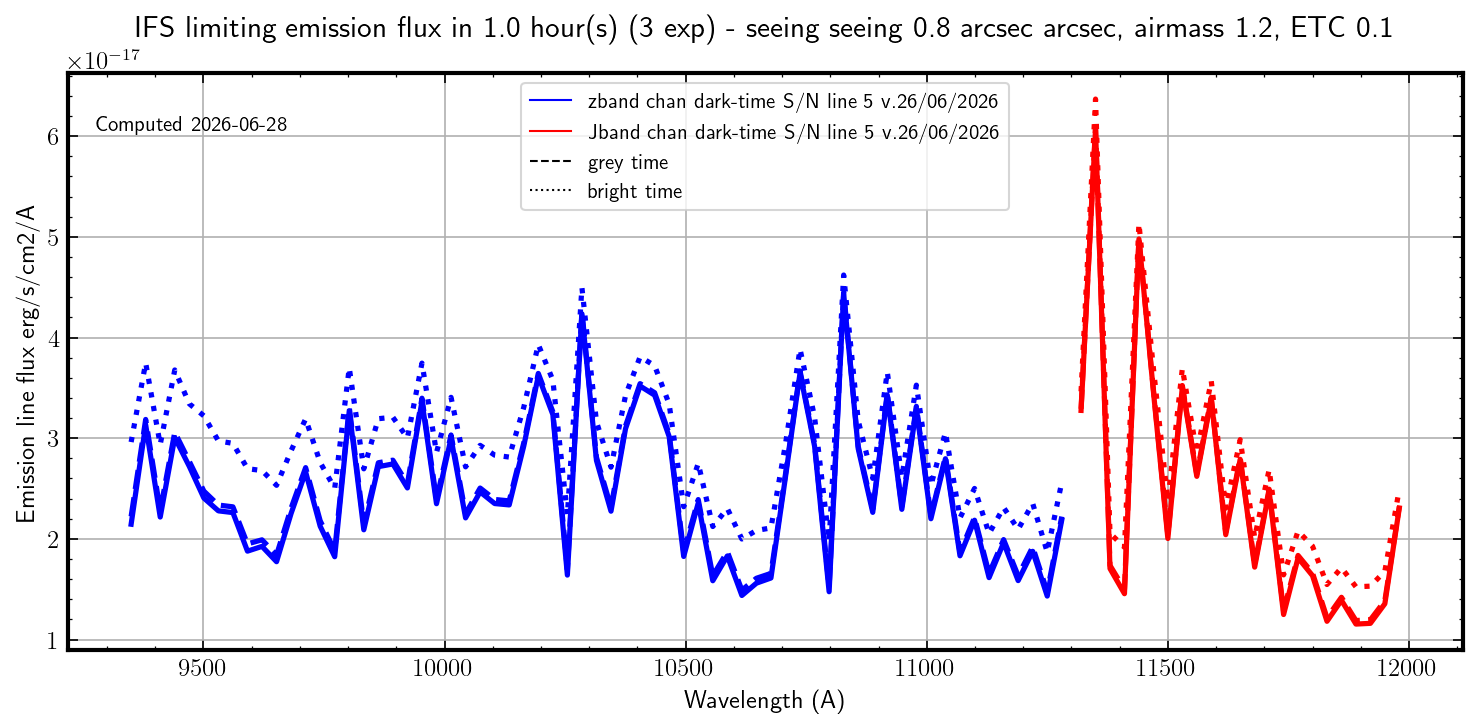

In [24]:
fig,ax = plt.subplots(1,1,figsize=(12,5))
labs = []
for d,c in zip(difs[0]['dlim'], ['blue','red']):
    lab = f"{d['chan']} chan dark-time S/N line {snr} v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(difs[1]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(difs[2]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Emission line flux erg/s/cm2/A')
see = 'GLAO' if full_obs['GLAO'] else f"seeing {see} arcsec"
integ = full_obs['NDIT']*full_obs['DIT']/3600
ax.set_title(f"IFS limiting emission flux in {integ} hour(s) ({full_obs['NDIT']} exp) - {see}, airmass {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [25]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(file_dir,f"{today}_{instru.name}_IFS_limiting_Lineflux.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(file_dir,f"{today}_{instru.name}_IFS_limiting_Lineflux.json")
with open(outres, "w") as f:
    json.dump(difs, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-06-28_iredMUSE_IFS_limiting_Lineflux.jpg
Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-06-28_iredMUSE_IFS_limiting_Lineflux.json
